# Stage 4 — Analysis & Visualization

**Goal:** Test whether female candidates cite proportionally more women than male candidates do.


## 0. Setup

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("..")
GENDER_COLORS = {"homme": "steelblue", "femme": "coral"}

df = pd.read_csv(PROJECT_ROOT / "data" / "citations_with_gender.csv", low_memory=False)
print(f"Citations loaded: {len(df):,}")
print(f"\nCandidate gender distribution:")
print(df.drop_duplicates("candidate_id")["candidate_sex"].value_counts())
print(f"\nCited-person gender distribution:")
print(df["cited_gender"].value_counts())

Citations loaded: 50,416

Candidate gender distribution:
candidate_sex
homme    14725
femme     1616
Name: count, dtype: int64

Cited-person gender distribution:
cited_gender
male                  30995
unknown               17073
female                 2337
non-binary                7
transgender female        4
Name: count, dtype: int64


In [37]:
queer = df[df["cited_gender"].isin(["transgender female", "non-binary"])]                                                                                   
print(queer[["cited_person_clean", "wikidata_label", "candidate_sex"]].drop_duplicates("cited_person_clean").to_string()) 

     cited_person_clean  wikidata_label candidate_sex
4416         Remy Huber  Rémy Huberdeau         homme
8648              De We  Anuna De Wever         femme


In [38]:
df.head()

,candidate_id,candidate_sex,candidate_party,candidate_name,year,cited_person,cited_person_clean,cited_gender,wikidata_id,wikidata_label
0,EL065_L_1973_03_001_01_1_PF_01,homme,Centre progrès et démocratie moderne;Union des...,Paul Barberot,1973,Paul BARBEROT,Paul Barberot,male,Q3370559,Paul Barberot
1,EL065_L_1973_03_001_01_1_PF_01,homme,Centre progrès et démocratie moderne;Union des...,Paul Barberot,1973,Jean-Marie BEAUDET,Jean-Marie Beaudet,male,Q358769,Jean-Marie Beaudet
2,EL065_L_1973_03_001_01_1_PF_02,homme,Parti socialiste;Mouvement des radicaux de gauche,Roland Monnet,1973,Roland MON NET,Roland Mon Net,unknown,NaN,NaN
3,EL065_L_1973_03_001_01_1_PF_02,homme,Parti socialiste;Mouvement des radicaux de gauche,Roland Monnet,1973,Pierre PERRIN,Pierre Perrin,male,Q3294482,Pierre Perrin
4,EL065_L_1973_03_001_01_1_PF_02,homme,Parti socialiste;Mouvement des radicaux de gauche,Roland Monnet,1973,Roland MONNET,Roland Monnet,unknown,NaN,NaN


## 0b. Descriptive overview — citation & gender composition

Despite the effort of trying to get the information on the cited political figures in manifestos, there is a gap between the figures which identified gender. I hypothetisy some of the following reasons:               
* Local and regional politicians are the most likely to be missing from Wikidata
* Wikidata's coverage of historical French political figures skews heavily male
                                                                                  
For our results, this means that the female citation reported (44% for female candidates, 5% for male) are computed only on resolved citations. The 33.9% unknown rate reflects Wikidata's known gender gap: women are systematically less likely to have Wikidata entries. Citation rates reported here are therefore conservative estimates, computed on the resolved subset only.

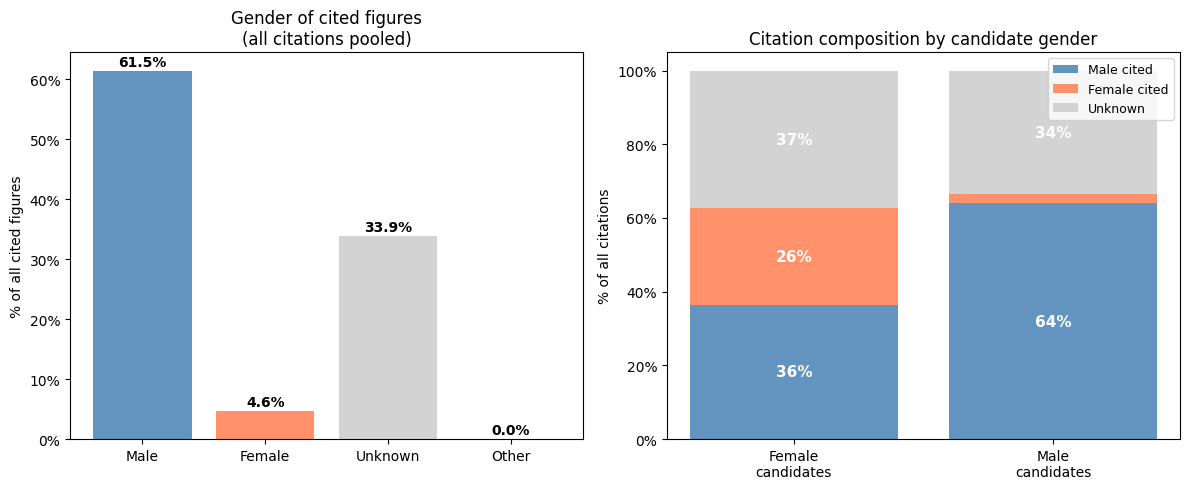

=== Panel A: overall cited gender ===
              count     %
cited_gender             
male          30995  61.5
female         2337   4.6
unknown       17073  33.9
other            11   0.0

=== Panel B: composition by candidate gender ===
cited_gender   male  female  unknown
candidate_sex                       
femme          36.5    26.3     37.2
homme          64.0     2.5     33.5


In [39]:
# ── Fig: Citation & gender composition overview ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A (left): overall gender of all cited figures (pooled)
gender_counts = (
    df['cited_gender']
    .replace({'non-binary': 'other', 'transgender female': 'other'})
    .value_counts()
    [['male', 'female', 'unknown', 'other']]
)
gender_pct = gender_counts / gender_counts.sum() * 100
colors_a = ['steelblue', 'coral', '#cccccc', '#aaaaaa']
bars = axes[0].bar(
    ['Male', 'Female', 'Unknown', 'Other'],
    gender_pct.values, color=colors_a, alpha=0.85
)
for bar, v in zip(bars, gender_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('% of all cited figures')
axes[0].set_title('Gender of cited figures\n(all citations pooled)')
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter())

# Panel B (right): citation composition by candidate gender (stacked %)
comp = (
    df.groupby(['candidate_sex', 'cited_gender'])
    .size()
    .unstack(fill_value=0)
    [['male', 'female', 'unknown']]
)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
labels = ['Female\ncandidates', 'Male\ncandidates']
bar_specs = [
    ('male',    'steelblue', 'Male cited'),
    ('female',  'coral',     'Female cited'),
    ('unknown', '#cccccc',   'Unknown'),
]
bottom = np.zeros(2)
for col, color, label in bar_specs:
    vals = comp_pct.loc[['femme', 'homme'], col].values
    axes[1].bar(labels, vals, bottom=bottom, color=color, alpha=0.85, label=label)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            axes[1].text(i, b + v / 2, f'{v:.0f}%', ha='center', va='center',
                         fontsize=11, color='white', fontweight='bold')
    bottom += vals
axes[1].set_ylabel('% of all citations')
axes[1].set_title('Citation composition by candidate gender')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter())

plt.tight_layout()
plt.savefig(Path("..") / "figures" / "fig_citation_composition.png", dpi=150, bbox_inches='tight')
plt.show()

print("=== Panel A: overall cited gender ===")
print(pd.DataFrame({'count': gender_counts, '%': gender_pct.round(1)}))
print("\n=== Panel B: composition by candidate gender ===")
print(comp_pct.round(1))

## 1. Core Question: Do female candidates cite more women?

For each candidate, we compute the share of their citations that go to female figures (among citations with known gender). We then compare this share between female and male candidates using a Mann-Whitney U test (non-parametric, robust to skewed distributions).

For all the time of the study, 1973 to 1993, women cite more women than men, and the true gap is likely larger than 44% vs 5%, not smaller

In [40]:
# Keep only citations with known gender
df_known = df[df["cited_gender"].isin(["male", "female"])].copy()

# Per candidate: share of citations going to female figures
per_candidate = (
    df_known.groupby(["candidate_id", "candidate_sex"])
    .apply(lambda g: (g["cited_gender"] == "female").mean())
    .reset_index(name="pct_female_cited")
)

female_scores = per_candidate[per_candidate["candidate_sex"] == "femme"]["pct_female_cited"]
male_scores   = per_candidate[per_candidate["candidate_sex"] == "homme"]["pct_female_cited"]

print(f"Female candidates with known citations: {len(female_scores)}")
print(f"Male candidates with known citations:   {len(male_scores)}")
print(f"\nMean % female cited — female candidates: {female_scores.mean()*100:.2f}%")
print(f"Mean % female cited — male candidates:   {male_scores.mean()*100:.2f}%")

stat, p = stats.mannwhitneyu(female_scores, male_scores, alternative="greater")
print(f"\nMann-Whitney U test (female > male):")
print(f"  U = {stat:.0f}, p = {p:.4f}")
print(f"  {'Significant at p<0.05' if p < 0.05 else 'Not significant'}")

Female candidates with known citations: 1320
Male candidates with known citations:   12262

Mean % female cited — female candidates: 43.99%
Mean % female cited — male candidates:   4.69%

Mann-Whitney U test (female > male):
  U = 12463618, p = 0.0000
  Significant at p<0.05


## 2. Visualization — Distribution of female citation share by candidate gender

## 2b. Top cited female figures — normalized by group size

Who are the women more prominent in politics? And who are bringing them to the spot?

Among men, the most cited women are Arlette Laguiller and Huguette Bouchardeau, and ocasionally they mentioned Dominique Voynet and Simone Veil,but all of them are below 5. 

Meanwhile among women, around 20% of the candidates mentioned Arlette Laguiller, and Gisele Halimi and Simone de Beauvoir were mentioned around 4% of candidates. 

It seems that male candidates cite women who entered  electoral politics (candidates, ministers). Female candidates cite women who theorised or fought for women's rights, intellectuals and activists. It's the difference between referencing a woman in politics versus referencing women as a cause.


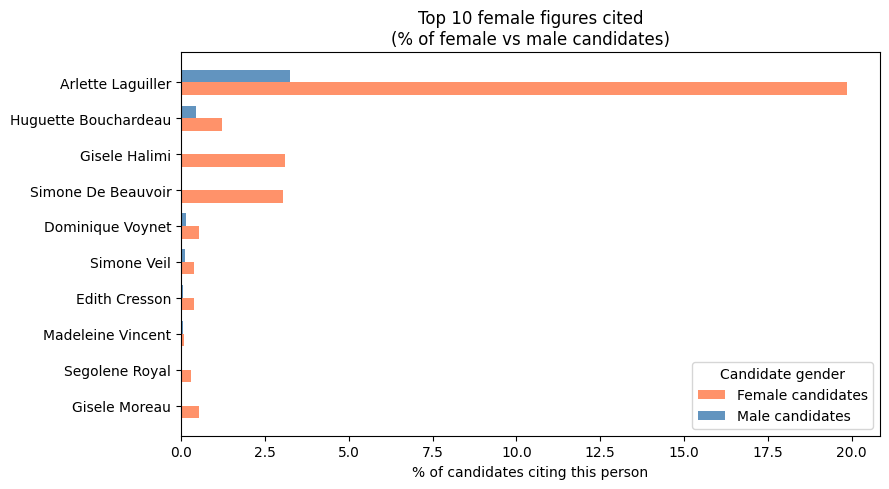

In [41]:
total_female_cands = df_known[df_known["candidate_sex"] == "femme"]["candidate_id"].nunique()
total_male_cands   = df_known[df_known["candidate_sex"] == "homme"]["candidate_id"].nunique()

top_pct = (
    df_known[df_known["cited_gender"] == "female"]
    .groupby(["cited_person_clean", "candidate_sex"])["candidate_id"]
    .nunique()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
    .head(10)
    .drop(columns="total")
)
top_pct["femme_pct"] = top_pct.get("femme", 0) / total_female_cands * 100
top_pct["homme_pct"] = top_pct.get("homme", 0) / total_male_cands * 100

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(top_pct))
width = 0.35
ax.barh([i + width/2 for i in x], top_pct["femme_pct"], width,
        color="coral", alpha=0.85, label="Female candidates")
ax.barh([i - width/2 for i in x], top_pct["homme_pct"], width,
        color="steelblue", alpha=0.85, label="Male candidates")
ax.set_yticks(list(x))
ax.set_yticklabels(top_pct.index)
ax.invert_yaxis()
ax.set_xlabel("% of candidates citing this person")
ax.set_title("Top 10 female figures cited\n(% of female vs male candidates)")
ax.legend(title="Candidate gender")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fig_top_female_pct.png", dpi=150)
plt.show()

## 2c. What do female candidates cite beyond women?

To understand differences in the overall political figures for men and for women. Is the dicurse different? Who are more salient among women and men? 

Top cited figures by female vs male candidates (all genders), normalized by group size. We then identify figures that appear in female top 20 but not male top 20, which are the distinctive references of female candidates.

In [42]:
df_all = df.copy()  # use full dataset, not just known-gender citations
total_f = df_all[df_all["candidate_sex"] == "femme"]["candidate_id"].nunique()
total_m = df_all[df_all["candidate_sex"] == "homme"]["candidate_id"].nunique()

def top_cited_pct(sex, n=20):
    return (
        df_all[df_all["candidate_sex"] == sex]
        .groupby("cited_person_clean")["candidate_id"]
        .nunique()
        .div(total_f if sex == "femme" else total_m)
        .mul(100)
        .sort_values(ascending=False)
        .head(n)
    )

female_top = top_cited_pct("femme", 20)
male_top   = top_cited_pct("homme", 20)

# Figures distinctive to female candidates
female_only = set(female_top.index) - set(male_top.index)
male_only   = set(male_top.index) - set(female_top.index)

print("=== Top 20 cited by FEMALE candidates (% of female manifestos) ===")
print(female_top.round(2).to_string())

print("\n=== Top 20 cited by MALE candidates (% of male manifestos) ===")
print(male_top.round(2).to_string())

print("\n=== In female top 20 but NOT male top 20 ===")
for name in female_top.index:
    if name in female_only:
        print(f"  {name:40s} {female_top[name]:.2f}% female")

print("\n=== In male top 20 but NOT female top 20 ===")
for name in male_top.index:
    if name in male_only:
        print(f"  {name:40s} {male_top[name]:.2f}% male")

=== Top 20 cited by FEMALE candidates (% of female manifestos) ===
cited_person_clean
Francois Mitterrand         20.54
Arlette Laguiller           16.21
Michel Rocard                5.01
Le Pen                       4.33
De Wendel                    4.27
Jean-Marie Le Pen            4.21
Brice Lalonde                4.15
Gisele Halimi                2.54
Jacques Monod                2.48
Jean Rostand                 2.48
Simone De Beauvoir           2.48
Jacques Chirac               1.73
Giscard D'Estaing            1.67
F. Mitterrand                1.18
Andre Lajoinie               1.05
Valery Giscard D'Estaing     1.05
Georges Pompidou             1.05
President Pompidou           0.99
R. Barre                     0.99
Huguette Bouchardeau         0.99

=== Top 20 cited by MALE candidates (% of male manifestos) ===
cited_person_clean
Francois Mitterrand               15.67
Michel Rocard                      4.31
Le Pen                             3.03
Jean-Marie Le Pen              

## 3. Temporal evolution — female citation share by year

Over the years of the study and for the citations that we know the gender, it is observed that female candidates cite almost half of the times another woman,but there are so few of them (9% of all candidates) that it barely moves the aggregate.

However, the presence of political figures over time has steadily and marginally increased over the study period, from 40% to 48% of unique cited figures for female candidates, and from 2% to 4% for male candidates. 

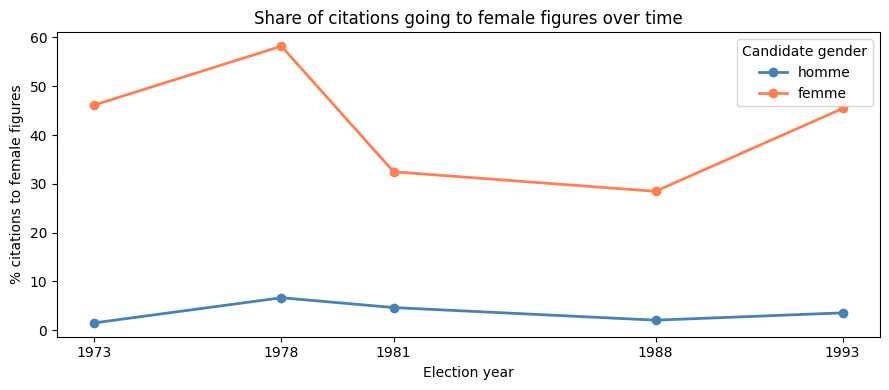

 year candidate_sex  pct_female_cited
 1973         femme         46.153846
 1973         homme          1.476840
 1978         femme         58.220025
 1978         homme          6.633528
 1981         femme         32.457496
 1981         homme          4.620668
 1988         femme         28.454172
 1988         homme          2.033347
 1993         femme         45.438596
 1993         homme          3.529783


In [43]:
temporal = (
    df_known.groupby(["year", "candidate_sex"])
    .apply(lambda g: (g["cited_gender"] == "female").mean() * 100)
    .reset_index(name="pct_female_cited")
)

fig, ax = plt.subplots(figsize=(9, 4))
for sex, color in GENDER_COLORS.items():
    subset = temporal[temporal["candidate_sex"] == sex]
    ax.plot(subset["year"], subset["pct_female_cited"],
            marker="o", color=color, linewidth=2, label=sex)

ax.set_xticks(sorted(temporal["year"].unique()))
ax.set_title("Share of citations going to female figures over time")
ax.set_xlabel("Election year")
ax.set_ylabel("% citations to female figures")
ax.legend(title="Candidate gender")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fig_temporal.png", dpi=150)
plt.show()

print(temporal.to_string(index=False))

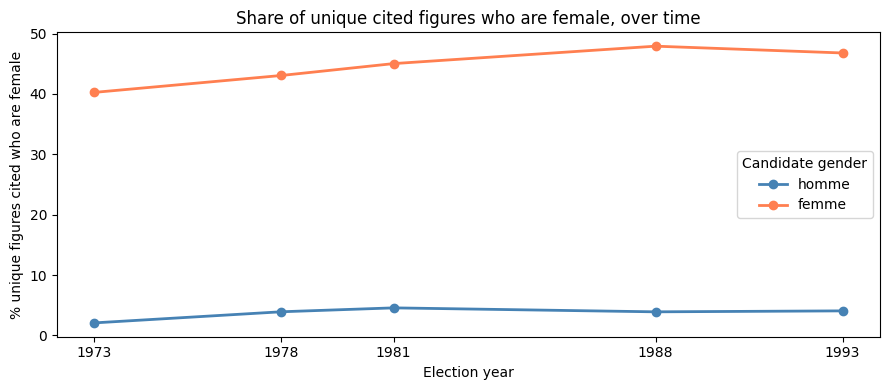

 year candidate_sex  pct_female_figures
 1973         femme           40.259740
 1973         homme            2.073579
 1978         femme           43.062201
 1978         homme            3.915171
 1981         femme           45.029240
 1981         homme            4.561404
 1988         femme           47.916667
 1988         homme            3.905447
 1993         femme           46.788991
 1993         homme            4.063522


In [44]:
# Share of *unique* cited figures who are female, per year × candidate gender
temporal_figures = (
    df_known.groupby(["year", "candidate_sex"])
    .apply(lambda g: g.drop_duplicates("cited_person_clean")["cited_gender"].eq("female").mean() * 100)
    .reset_index(name="pct_female_figures")
)

fig, ax = plt.subplots(figsize=(9, 4))
for sex, color in GENDER_COLORS.items():
    subset = temporal_figures[temporal_figures["candidate_sex"] == sex]
    ax.plot(subset["year"], subset["pct_female_figures"],
            marker="o", color=color, linewidth=2, label=sex)

ax.set_xticks(sorted(temporal_figures["year"].unique()))
ax.set_title("Share of unique cited figures who are female, over time")
ax.set_xlabel("Election year")
ax.set_ylabel("% unique figures cited who are female")
ax.legend(title="Candidate gender")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "fig_temporal_figures.png", dpi=150)
plt.show()

print(temporal_figures.to_string(index=False))